In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Level A

### 1.1 A1. Data types & Attributes 

In [35]:
df = pd.read_csv("ramen-ratings.csv")

In [36]:
print("INFORMATION OF DataSet\n")
df.info()
print("\nDataTypes\n")
print(df.dtypes)

INFORMATION OF DataSet

<class 'pandas.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Review #  2580 non-null   int64
 1   Brand     2580 non-null   str  
 2   Variety   2580 non-null   str  
 3   Style     2578 non-null   str  
 4   Country   2580 non-null   str  
 5   Stars     2580 non-null   str  
 6   Top Ten   41 non-null     str  
dtypes: int64(1), str(6)
memory usage: 141.2 KB

DataTypes

Review #    int64
Brand         str
Variety       str
Style         str
Country       str
Stars         str
Top Ten       str
dtype: object


In [37]:
df.head(10)

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1,NaN
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN
5,2575,Samyang Foods,Kimchi song Song Ramen,Pack,South Korea,4.75,NaN
6,2574,Acecook,Spice Deli Tantan Men With Cilantro,Cup,Japan,4,NaN
7,2573,Ikeda Shoku,Nabeyaki Kitsune Udon,Tray,Japan,3.75,NaN
8,2572,Ripe'n'Dry,Hokkaido Soy Sauce Ramen,Pack,Japan,0.25,NaN
9,2571,KOKA,The Original Spicy Stir-Fried Noodles,Pack,Singapore,2.5,NaN


1. Review #: Qualitative data and considered to be the **Nominal**, due to numerical values which represents IDs.
2. Brand: Qulitative data and it's **Nominal**, because it's simply the names of Brands.
3. Variety: Qualitative data and it's also **Nominal**, because it represents different flavours of ramen.
4. Style: Qualitative **Nominal** data, because it represents type of how your ramen will be packed.
5. Country: Qualitative **Nominal** data - simply represents the country.
6. Stars: Quantitative data, which can be either **Continuous**, because it's measures the ramen quality on a scale that includes decimal numbers. But it also might be considered as Qualitative data **Ordinal**, due to its representing the rating of ramen.

In [38]:
print(df["Top Ten"].dropna().head(10))

616     2016 #10
633      2016 #1
655      2016 #8
673      2016 #5
752      2016 #9
891      2016 #7
942     2015 #10
963      2015 #7
995      2015 #4
1059     2015 #9
Name: Top Ten, dtype: str


7. Top Ten: We clearly see that it shows ranking, which means it's Qualitative **Ordinal** data.

### 1.2 A2 Descriptive Statistics

In [39]:
num_cols = df.select_dtypes(include = "number")
print(num_cols)

      Review #
0         2580
1         2579
2         2578
3         2577
4         2576
...        ...
2575         5
2576         4
2577         3
2578         2
2579         1

[2580 rows x 1 columns]


We have only **Review** as a numerical column, because column **Stars** is being treated as an "object" -> We need to convert it into numerical values.

In [40]:
df["Stars"] = pd.to_numeric(df["Stars"] , errors = "coerce")

In [41]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(numeric_cols)

Index(['Review #', 'Stars'], dtype='str')


Review # Statistics
Mean: 1290.5000 | Median: 1290.5000 | Mode: 1
Range: 2579.0000 | Variance: 554915.0000 | Std Dev: 744.9262
IQR: 1289.5000 (Q1: 645.75, Q3: 1935.25)
Outlier Count: 0
Unique Outlier Values: []

Stars Statistics
Mean: 3.6547 | Median: 3.7500 | Mode: 4.0
Range: 5.0000 | Variance: 1.0309 | Std Dev: 1.0153
IQR: 1.0000 (Q1: 3.25, Q3: 4.25)
Outlier Count: 129
Unique Outlier Values: [np.float64(0.0), np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(0.9), np.float64(1.0), np.float64(1.1), np.float64(1.25), np.float64(1.5)]



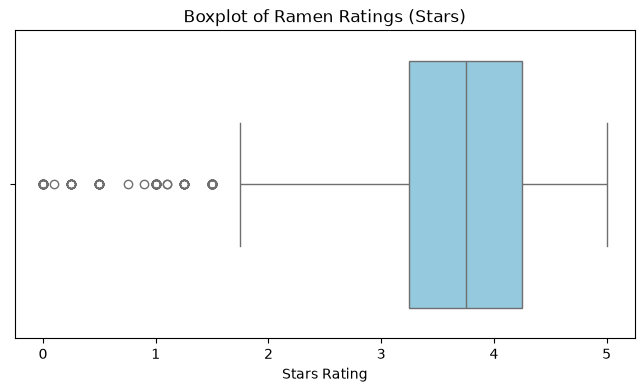

In [42]:
for col in numeric_cols:
    s = df[col].dropna()
    
    mean_val = s.mean()
    median_val = s.median()
    mode_val = s.mode()[0]
    range_val = s.max() - s.min()
    var_val = s.var()
    std_val = s.std()
    
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = s[(s < lower_bound) | (s > upper_bound)]
    
    print(f"{col} Statistics")
    print(f"Mean: {mean_val:.4f} | Median: {median_val:.4f} | Mode: {mode_val}")
    print(f"Range: {range_val:.4f} | Variance: {var_val:.4f} | Std Dev: {std_val:.4f}")
    print(f"IQR: {iqr:.4f} (Q1: {q1}, Q3: {q3})")
    print(f"Outlier Count: {len(outliers)}")
    print(f"Unique Outlier Values: {sorted(outliers.unique())}\n")

# Boxplot for Stars
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Stars'], color='skyblue')
plt.title('Boxplot of Ramen Ratings (Stars)')
plt.xlabel('Stars Rating')
plt.show()

### 1.3 A3. Handling Missing Data

In [43]:
from sklearn.impute import KNNImputer

In [44]:
# Artificially introduce 5% NaN values using a fixed random seed
np.random.seed(42)
stars_missing = df['Stars'].copy()
mask = np.random.rand(len(stars_missing)) < 0.05
stars_missing[mask] = np.nan

In [45]:
# Method A: Constant Value Imputation (e.g., 0)
df['Stars_const'] = stars_missing.fillna(0.0)

# Method B: Mean / Median / Mode Imputation
df['Stars_mean'] = stars_missing.fillna(stars_missing.mean())
df['Stars_median'] = stars_missing.fillna(stars_missing.median())
df['Stars_mode'] = stars_missing.fillna(stars_missing.mode()[0])

# Method C: Predictive Imputation (KNN with k=5)
knn_data = pd.DataFrame({'Review #': df['Review #'], 'Stars': stars_missing})
imputer = KNNImputer(n_neighbors=5)
df['Stars_knn'] = imputer.fit_transform(knn_data)[:, 1]

In [46]:
comparison_data = {
    'Dataset Version': [
        'Original (Clean)',
        'With 5% Missing (Dropped)',
        'Constant Imputation (0.0)',
        'Mean Imputation',
        'Median Imputation',
        'Mode Imputation',
        'KNN Imputation (k=5)'
    ],
    'Mean': [
        df['Stars'].mean(),
        stars_missing.mean(),
        df['Stars_const'].mean(),
        df['Stars_mean'].mean(),
        df['Stars_median'].mean(),
        df['Stars_mode'].mean(),
        df['Stars_knn'].mean()
    ],
    'Std Deviation': [
        df['Stars'].std(),
        stars_missing.std(),
        df['Stars_const'].std(),
        df['Stars_mean'].std(),
        df['Stars_median'].std(),
        df['Stars_mode'].std(),
        df['Stars_knn'].std()
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("COMPARISON TABLE")
print(comparison_df.to_string(index=False))

COMPARISON TABLE
          Dataset Version     Mean  Std Deviation
         Original (Clean) 3.654676       1.015331
With 5% Missing (Dropped) 3.650552       1.018437
Constant Imputation (0.0) 3.459535       1.282188
          Mean Imputation 3.650552       0.991423
        Median Imputation 3.655756       0.991670
          Mode Imputation 3.668837       0.994473
     KNN Imputation (k=5) 3.654314       0.998714


In [47]:
imputed_comparison = pd.DataFrame({
    'Review #': df.loc[mask, 'Review #'],
    'Original Stars': df.loc[mask, 'Stars'],
    'Constant (0.0)': df.loc[mask, 'Stars_const'],
    'Mean Fill': df.loc[mask, 'Stars_mean'],
    'Median Fill': df.loc[mask, 'Stars_median'],
    'Mode Fill': df.loc[mask, 'Stars_mode'],
    'KNN Fill': df.loc[mask, 'Stars_knn']
})

print("SAMPLE OF IMPUTED VALUES FOR MISSING ROWS")
print(imputed_comparison.head(10))

SAMPLE OF IMPUTED VALUES FOR MISSING ROWS
     Review #  Original Stars  Constant (0.0)  Mean Fill  Median Fill  \
10       2570            5.00             0.0   3.650552         3.75   
29       2551            4.00             0.0   3.650552         3.75   
42       2538            5.00             0.0   3.650552         3.75   
58       2522            5.00             0.0   3.650552         3.75   
72       2508            3.75             0.0   3.650552         3.75   
98       2482            4.75             0.0   3.650552         3.75   
100      2480            4.25             0.0   3.650552         3.75   
128      2452            5.00             0.0   3.650552         3.75   
145      2435            3.50             0.0   3.650552         3.75   
168      2412            3.25             0.0   3.650552         3.75   

     Mode Fill  KNN Fill  
10         4.0      3.30  
29         4.0      4.55  
42         4.0      4.10  
58         4.0      4.50  
72         4.0     

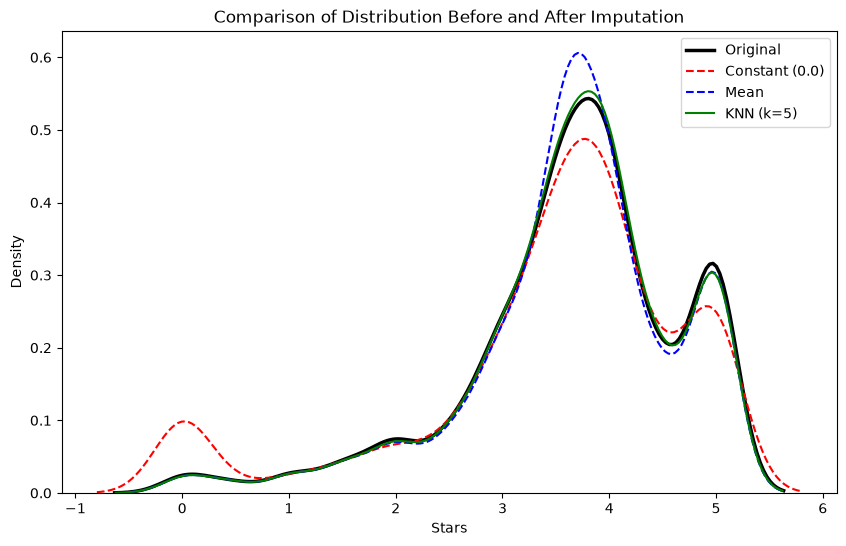

In [48]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df['Stars'], label='Original', color='black', linewidth=2.5)
sns.kdeplot(df['Stars_const'], label='Constant (0.0)', color='red', linestyle='--')
sns.kdeplot(df['Stars_mean'], label='Mean', color='blue', linestyle='--')
sns.kdeplot(df['Stars_knn'], label='KNN (k=5)', color='green', linestyle='-')

plt.title('Comparison of Distribution Before and After Imputation')
plt.xlabel('Stars')
plt.ylabel('Density')
plt.legend()
plt.show()

For constant imputation, filling the missing values with 0.0 was super easy and fast to code. However, it completely ruined our data averages. The original mean was 3.6547, but putting zeros brought it all the way down to 3.4644. It also blew up the standard deviation from 1.0153 to 1.2741 because zero is nowhere near the typical ratings.

Using mean imputation kept our average at 3.6514, which matched the dataset before filling in the blanks. The problem is that repeating the same average number 132 times squeezed our standard deviation down to 0.9874. Median and mode did almost the same thing by shifting the averages slightly higher to 3.6565 and 3.6693 while still shrinking the standard deviation. These simple methods are quick, but they completely ignore how other columns relate to each other.

KNN imputation gave us the most realistic numbers overall. It was a bit trickier to set up and took more computer effort since it had to calculate distances between rows. But because it used patterns from neighboring entries, its standard deviation came out to 0.9961. This was the closest we got to the original standard deviation of 1.0153 without pulling down the mean.

# Level B

### 2.1 B1. Normalization & Standardization

In [49]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df = pd.read_csv('WineQT.csv')

In [50]:
summary = pd.DataFrame(
    {
        'Min': df.min(),
        'Max': df.max(),
        'Mean': df.mean(),
        'Std Dev': df.std(),
    }
)
print(summary)

                          Min         Max        Mean     Std Dev
fixed acidity         4.60000    15.90000    8.311111    1.747595
volatile acidity      0.12000     1.58000    0.531339    0.179633
citric acid           0.00000     1.00000    0.268364    0.196686
residual sugar        0.90000    15.50000    2.532152    1.355917
chlorides             0.01200     0.61100    0.086933    0.047267
free sulfur dioxide   1.00000    68.00000   15.615486   10.250486
total sulfur dioxide  6.00000   289.00000   45.914698   32.782130
density               0.99007     1.00369    0.996730    0.001925
pH                    2.74000     4.01000    3.311015    0.156664
sulphates             0.33000     2.00000    0.657708    0.170399
alcohol               8.40000    14.90000   10.442111    1.082196
quality               3.00000     8.00000    5.657043    0.805824
Id                    0.00000  1597.00000  804.969379  463.997116


In [51]:
features = ["total sulfur dioxide", "pH"]

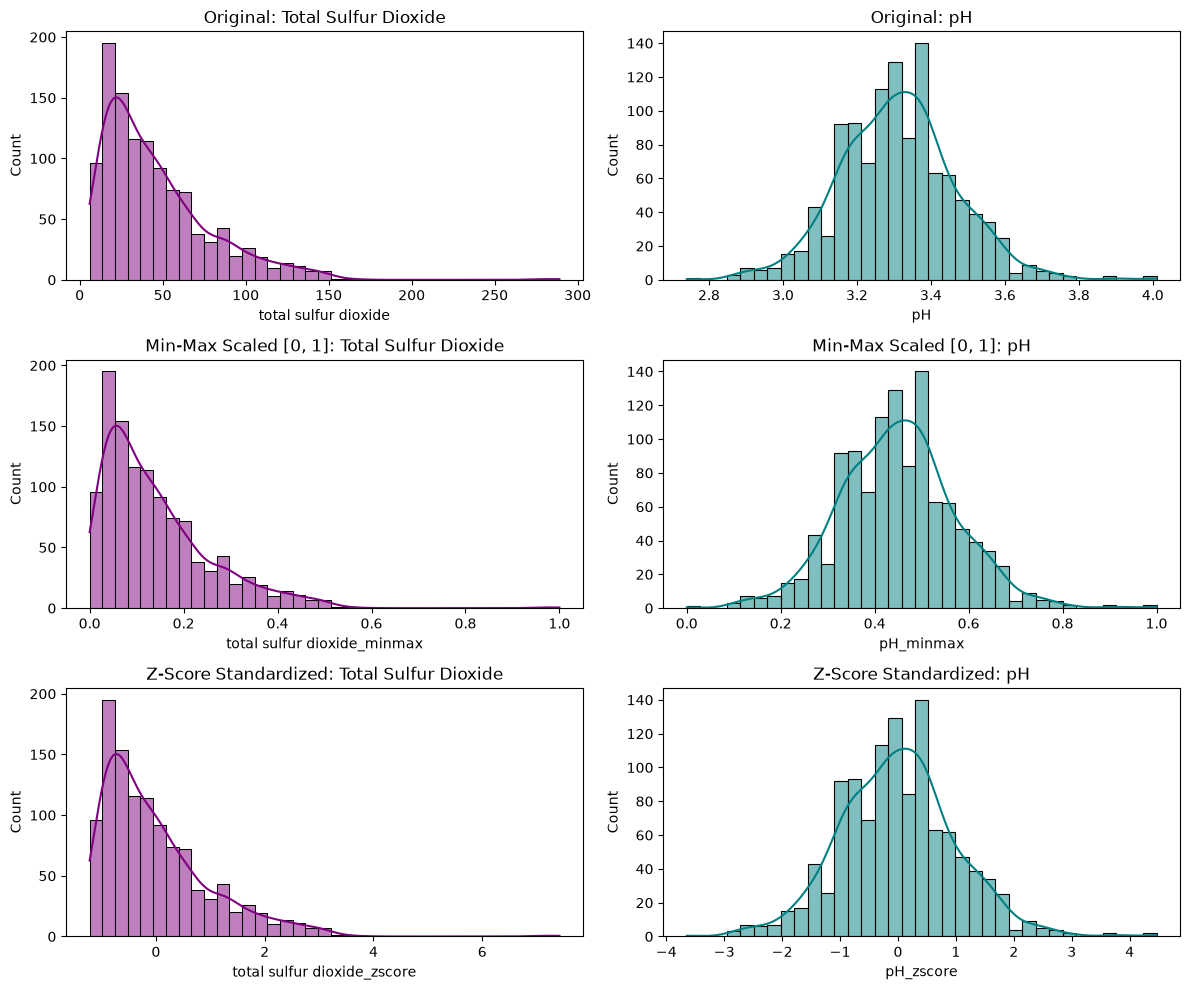

In [52]:


min_max_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    min_max_scaler.fit_transform(df[features]),
    columns=[f'{c}_minmax' for c in features],
)

standard_scaler = StandardScaler()
df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df[features]),
    columns=[f'{c}_zscore' for c in features],
)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

sns.histplot(
    df['total sulfur dioxide'], kde=True, ax=axes[0, 0], color='purple'
)
axes[0, 0].set_title('Original: Total Sulfur Dioxide')

sns.histplot(df['pH'], kde=True, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Original: pH')

sns.histplot(
    df_minmax['total sulfur dioxide_minmax'],
    kde=True,
    ax=axes[1, 0],
    color='purple',
)
axes[1, 0].set_title('Min-Max Scaled [0, 1]: Total Sulfur Dioxide')

sns.histplot(
    df_minmax['pH_minmax'], kde=True, ax=axes[1, 1], color='teal'
)
axes[1, 1].set_title('Min-Max Scaled [0, 1]: pH')

sns.histplot(
    df_standard['total sulfur dioxide_zscore'],
    kde=True,
    ax=axes[2, 0],
    color='purple',
)
axes[2, 0].set_title('Z-Score Standardized: Total Sulfur Dioxide')

sns.histplot(
    df_standard['pH_zscore'], kde=True, ax=axes[2, 1], color='teal'
)
axes[2, 1].set_title('Z-Score Standardized: pH')

plt.tight_layout()
plt.show()

**Min-Max Normalization**
* Best for algorithms that need inputs strictly bounded between 0 and 1, such as Neural Networks and distance-based models like K-Nearest Neighbors (KNN).* Works well when data has fixed upper and lower limits without extreme outliers.
* In our run, it forced all numbers from both features into the range $[0.0, 1.0]$.

**Z-Score Standardization**

* Best for algorithms that assume data follows a normal bell curve, such as Principal Component Analysis (PCA), Support Vector Machines (SVM), and Linear/Logistic Regression.
* Handles extreme values better than Min-Max because it does not squash the rest of the values into a tiny range.
* In our run, it centered both distributions around a mean of 0.0 with a standard deviation of 1.0.

### 2.2 B2. Feature Creation & Discretization

In [53]:
# Feature creation
df['bound_sulfur_dioxide'] = df['total sulfur dioxide'] - df['free sulfur dioxide']

df[['total sulfur dioxide', 'free sulfur dioxide', 'bound_sulfur_dioxide']].head()

,total sulfur dioxide,free sulfur dioxide,bound_sulfur_dioxide
0,34.0,11.0,23.0
1,67.0,25.0,42.0
2,54.0,15.0,39.0
3,60.0,17.0,43.0
4,34.0,11.0,23.0


In [54]:
# discretization
df['alcohol_eq_width'], width_bins = pd.cut(
    df['alcohol'], 
    bins=3, 
    labels=['Low', 'Medium', 'High'], 
    retbins=True
)

df['alcohol_eq_freq'], freq_bins = pd.qcut(
    df['alcohol'], 
    q=3, 
    labels=['Low', 'Medium', 'High'], 
    retbins=True
)

In [56]:
print("\nBin Boundaries")
print("Equal-Width Cutoffs:", np.round(width_bins, 2))
print("Equal-Frequency Cutoffs:", np.round(freq_bins, 2))

# Print Row Counts
print("\nBin Row Counts")
print("Equal-Width Counts:")
print(df['alcohol_eq_width'].value_counts().sort_index())
print("\nEqual-Frequency Counts:")
print(df['alcohol_eq_freq'].value_counts().sort_index())

ohe_df = pd.get_dummies(df['alcohol_eq_freq'], prefix='alcohol', dtype=int)

print("\nOne-Hot Encoded Features")
display(ohe_df.head())


Bin Boundaries
Equal-Width Cutoffs: [ 8.39 10.57 12.73 14.9 ]
Equal-Frequency Cutoffs: [ 8.4  9.7 10.8 14.9]

Bin Row Counts
Equal-Width Counts:
alcohol_eq_width
Low       699
Medium    405
High       39
Name: count, dtype: int64

Equal-Frequency Counts:
alcohol_eq_freq
Low       390
Medium    377
High      376
Name: count, dtype: int64

One-Hot Encoded Features


,alcohol_Low,alcohol_Medium,alcohol_High
0,1,0,0
1,0,1,0
2,0,1,0
3,0,1,0
4,1,0,0


 **Impact on Machine Learning Models**

 * Feature Creation: Adding domain-specific features like bound_sulfur_dioxide provides algorithms with explicit chemical signals directly linked to wine stability, saving tree models or linear regressors from having to learn complex subtraction patterns on their own.
 * Equal-Width Binning: Creates easy-to-understand intervals, but when data is right-skewed (like wine alcohol levels), it leaves high-end bins with very few samples ($39$ vs $699$). This imbalance can cause models to underperform when predicting high-alcohol categories.
 * Equal-Frequency Binning: Solves class imbalance by ensuring every bin gets roughly $33\%$ of the dataset (~$380$ samples). This makes it much better for training classifiers, though interval widths vary ($1.3$ for Low vs. $4.1$ for High).
 * One-Hot Encoding: Allows linear models, logistic regression, and neural networks to process non-numeric categorical data without mistakenly assuming an arbitrary math relationship (e.g., treating 'High' as 3X greater than 'Low'). However, it increases dataset dimensionality.

### 3 Additional Analytical Tasks

#### 3.1 D1. Measures of Similarity and Dissimilarity 